In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

Path('../outputs').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

BRAND_COLORS = {
    'Luminos':       '#2563EB',
    'Dove':          '#DC2626',
    'Pantene':       '#D97706',
    'Suave':         '#059669',
    'Private Label': '#6B7280',
}

MARKET_TYPE_COLORS = {
    'declining': '#DC2626',
    'stable':    '#6B7280',
    'growing':   '#059669',
}

print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv('../data/nielsen_weekly.csv', parse_dates=['week_end_date'])
market_class = pd.read_csv('../data/market_classification.csv')

# Merge market type onto main data
df = df.merge(market_class[['market', 'market_type']], on='market', how='left')

print(f'Main data shape: {df.shape}')
print(f'Market classification:\n{market_class[["market","market_type","slope_annual_pp"]].to_string(index=False)}')

Main data shape: (15600, 19)
Market classification:
      market market_type  slope_annual_pp
 San Antonio   declining           -1.813
      Dallas   declining           -1.353
     Chicago   declining           -1.306
 Los Angeles   declining           -0.850
     Detroit      stable           -0.143
     Phoenix      stable            0.102
Philadelphia     growing            0.530
    New York     growing            0.543
     Houston     growing            0.849
     Seattle     growing            1.246


In [3]:
# National ACV by brand (avg across all markets, channels, weeks)
national_acv = (
    df.groupby('brand')['acv_distribution']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'acv_distribution': 'avg_acv'})
)

print('National Average ACV Distribution by Brand:')
for _, row in national_acv.iterrows():
    bar = '█' * int(row['avg_acv'] * 40)
    print(f"  {row['brand']:<15} {row['avg_acv']:.1%}  {bar}")

National Average ACV Distribution by Brand:
  Dove            94.0%  █████████████████████████████████████
  Suave           91.0%  ████████████████████████████████████
  Pantene         89.0%  ███████████████████████████████████
  Private Label   85.0%  ██████████████████████████████████
  Luminos         67.4%  ██████████████████████████


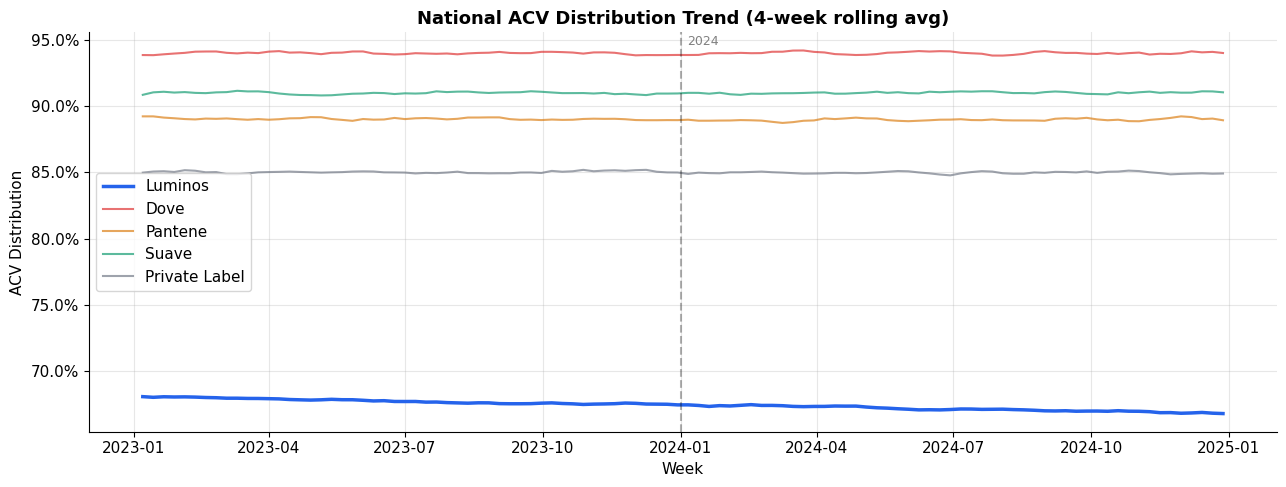

In [4]:
# ACV trend over time: Luminos vs competitors (4-week rolling avg)
acv_trend = (
    df.groupby(['week_end_date', 'brand'])['acv_distribution']
    .mean()
    .reset_index()
    .sort_values(['brand', 'week_end_date'])
)
acv_trend['acv_4w_ma'] = (
    acv_trend.groupby('brand')['acv_distribution']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(13, 5))

for brand in ['Luminos', 'Dove', 'Pantene', 'Suave', 'Private Label']:
    sub = acv_trend[acv_trend['brand'] == brand]
    lw  = 2.5 if brand == 'Luminos' else 1.5
    ax.plot(sub['week_end_date'], sub['acv_4w_ma'],
            color=BRAND_COLORS[brand], label=brand, linewidth=lw,
            alpha=1.0 if brand == 'Luminos' else 0.65)

ax.axvline(pd.Timestamp('2024-01-01'), color='black', linestyle='--', alpha=0.3)
ax.text(pd.Timestamp('2024-01-05'), ax.get_ylim()[1] * 0.99, '2024', fontsize=9, color='gray')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('National ACV Distribution Trend (4-week rolling avg)', fontsize=13, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('ACV Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/02_acv_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Luminos ACV: Y1 vs Y2 by market, ranked by ACV change
luminos_df = df[df['brand'] == 'Luminos'].copy()
luminos_df['year'] = luminos_df['week_index'].apply(lambda x: 'Y1' if x < 52 else 'Y2')

acv_by_market = (
    luminos_df.groupby(['market', 'market_type', 'year'])['acv_distribution']
    .mean()
    .unstack('year')
    .assign(acv_change_pp=lambda x: (x['Y2'] - x['Y1']) * 100)
    .reset_index()
    .sort_values('acv_change_pp')
)

print('Luminos ACV Distribution: Y1 vs Y2 by Market')
print('─' * 65)
print(f'{"Market":<15} {"Type":<12} {"Y1 ACV":>8} {"Y2 ACV":>8} {"Δ pp":>8}')
print('─' * 65)
for _, row in acv_by_market.iterrows():
    direction = '▼' if row['acv_change_pp'] < -0.5 else ('▲' if row['acv_change_pp'] > 0.3 else '→')
    print(f"{row['market']:<15} {row['market_type']:<12} "
          f"{row['Y1']:>7.1%} {row['Y2']:>8.1%} {row['acv_change_pp']:>+7.2f} {direction}")
print('─' * 65)

Luminos ACV Distribution: Y1 vs Y2 by Market
─────────────────────────────────────────────────────────────────
Market          Type           Y1 ACV   Y2 ACV     Δ pp
─────────────────────────────────────────────────────────────────
San Antonio     declining      65.4%    60.5%   -4.93 ▼
Dallas          declining      65.8%    61.6%   -4.25 ▼
Chicago         declining      66.1%    62.3%   -3.85 ▼
Los Angeles     declining      67.2%    65.5%   -1.70 ▼
Phoenix         stable         68.3%    69.0%   +0.69 ▲
Detroit         stable         68.5%    69.3%   +0.76 ▲
Houston         growing        68.5%    69.6%   +1.00 ▲
New York        growing        68.8%    70.4%   +1.59 ▲
Philadelphia    growing        68.9%    70.6%   +1.74 ▲
Seattle         growing        69.5%    72.5%   +2.97 ▲
─────────────────────────────────────────────────────────────────


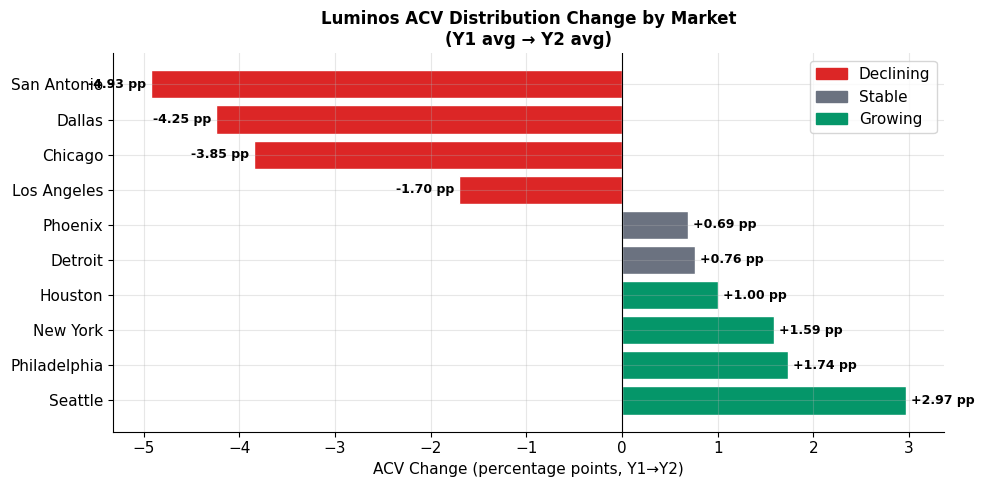

In [6]:
# Chart: ACV change by market, colored by market type
fig, ax = plt.subplots(figsize=(10, 5))

colors = [MARKET_TYPE_COLORS[t] for t in acv_by_market['market_type']]
bars = ax.barh(acv_by_market['market'], acv_by_market['acv_change_pp'], color=colors, edgecolor='white')

for bar, val in zip(bars, acv_by_market['acv_change_pp']):
    x = bar.get_width() + (0.05 if val >= 0 else -0.05)
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f} pp', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
patches = [mpatches.Patch(color=MARKET_TYPE_COLORS[t], label=t.capitalize())
           for t in ['declining', 'stable', 'growing']]
ax.legend(handles=patches)
ax.set_xlabel('ACV Change (percentage points, Y1→Y2)')
ax.set_title('Luminos ACV Distribution Change by Market\n(Y1 avg → Y2 avg)', fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/02_acv_change_by_market.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# National velocity by brand (avg across all markets, channels, weeks)
national_velocity = (
    df.groupby('brand')['velocity']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'velocity': 'avg_velocity'})
)

print('National Average Velocity ($/pt ACV) by Brand:')
for _, row in national_velocity.iterrows():
    bar = '█' * int(row['avg_velocity'] / 2)
    print(f"  {row['brand']:<15} ${row['avg_velocity']:.2f}  {bar}")

National Average Velocity ($/pt ACV) by Brand:
  Dove            $42.53  █████████████████████
  Pantene         $36.16  ██████████████████
  Suave           $28.37  ██████████████
  Luminos         $28.28  ██████████████
  Private Label   $18.47  █████████


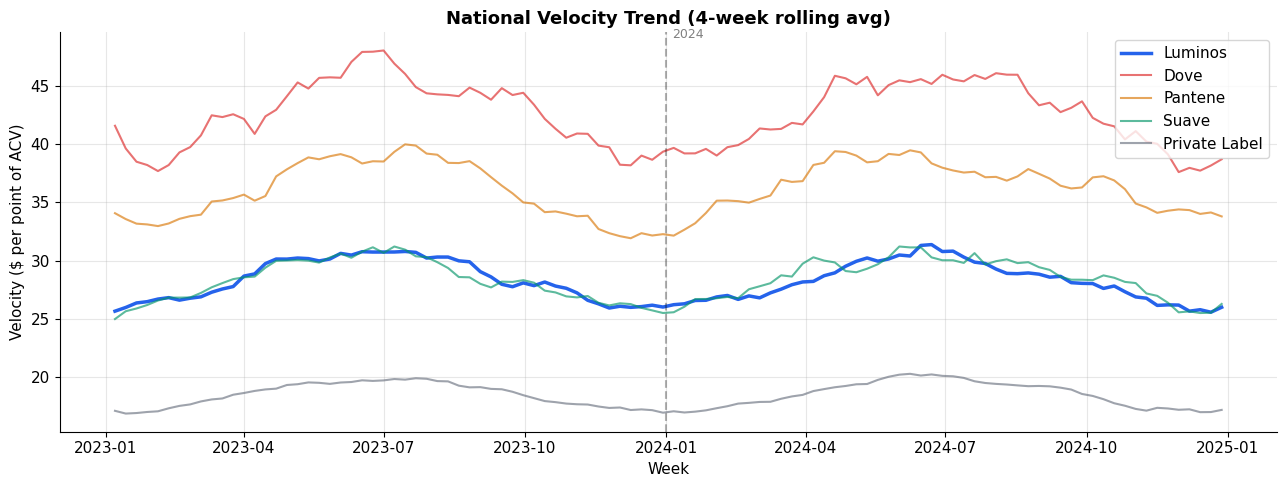

In [8]:
# Velocity trend over time: all brands (4-week rolling avg)
vel_trend = (
    df.groupby(['week_end_date', 'brand'])['velocity']
    .mean()
    .reset_index()
    .sort_values(['brand', 'week_end_date'])
)
vel_trend['vel_4w_ma'] = (
    vel_trend.groupby('brand')['velocity']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(13, 5))

for brand in ['Luminos', 'Dove', 'Pantene', 'Suave', 'Private Label']:
    sub = vel_trend[vel_trend['brand'] == brand]
    lw  = 2.5 if brand == 'Luminos' else 1.5
    ax.plot(sub['week_end_date'], sub['vel_4w_ma'],
            color=BRAND_COLORS[brand], label=brand, linewidth=lw,
            alpha=1.0 if brand == 'Luminos' else 0.65)

ax.axvline(pd.Timestamp('2024-01-01'), color='black', linestyle='--', alpha=0.3)
ax.text(pd.Timestamp('2024-01-05'), ax.get_ylim()[1] * 0.99, '2024', fontsize=9, color='gray')
ax.set_title('National Velocity Trend (4-week rolling avg)', fontsize=13, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Velocity ($ per point of ACV)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/02_velocity_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Luminos velocity: Y1 vs Y2 by market
vel_by_market = (
    luminos_df.groupby(['market', 'market_type', 'year'])['velocity']
    .mean()
    .unstack('year')
    .assign(vel_change_pct=lambda x: ((x['Y2'] - x['Y1']) / x['Y1']) * 100)
    .reset_index()
    .sort_values('vel_change_pct')
)

print('Luminos Velocity ($/pt ACV): Y1 vs Y2 by Market')
print('─' * 65)
print(f'{"Market":<15} {"Type":<12} {"Y1 Vel":>8} {"Y2 Vel":>8} {"Δ %":>8}')
print('─' * 65)
for _, row in vel_by_market.iterrows():
    direction = '▼' if row['vel_change_pct'] < -2 else ('▲' if row['vel_change_pct'] > 1 else '→')
    print(f"{row['market']:<15} {row['market_type']:<12} "
          f"${row['Y1']:>6.2f}  ${row['Y2']:>6.2f} {row['vel_change_pct']:>+7.1f}% {direction}")
print('─' * 65)

Luminos Velocity ($/pt ACV): Y1 vs Y2 by Market
─────────────────────────────────────────────────────────────────
Market          Type           Y1 Vel   Y2 Vel      Δ %
─────────────────────────────────────────────────────────────────
Dallas          declining    $ 27.86  $ 26.22    -5.9% ▼
San Antonio     declining    $ 27.84  $ 26.22    -5.8% ▼
Chicago         declining    $ 27.97  $ 27.12    -3.0% ▼
Los Angeles     declining    $ 28.20  $ 27.53    -2.4% ▼
Detroit         stable       $ 28.96  $ 28.49    -1.6% →
Philadelphia    growing      $ 28.73  $ 28.61    -0.4% →
New York        growing      $ 28.64  $ 29.02    +1.3% ▲
Phoenix         stable       $ 28.58  $ 28.98    +1.4% ▲
Houston         growing      $ 28.39  $ 29.45    +3.7% ▲
Seattle         growing      $ 28.47  $ 30.33    +6.5% ▲
─────────────────────────────────────────────────────────────────


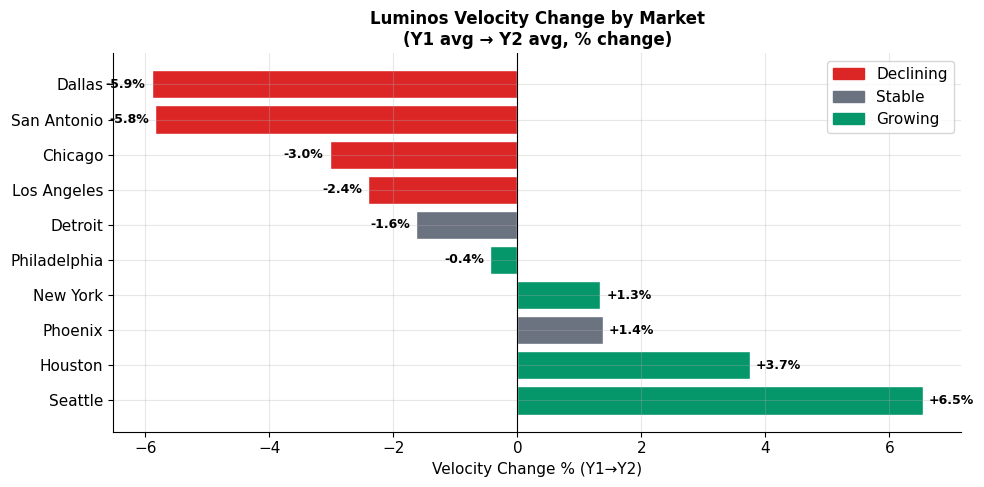

In [10]:
# Chart: velocity % change by market
fig, ax = plt.subplots(figsize=(10, 5))

colors = [MARKET_TYPE_COLORS[t] for t in vel_by_market['market_type']]
bars = ax.barh(vel_by_market['market'], vel_by_market['vel_change_pct'], color=colors, edgecolor='white')

for bar, val in zip(bars, vel_by_market['vel_change_pct']):
    x = bar.get_width() + (0.1 if val >= 0 else -0.1)
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
patches = [mpatches.Patch(color=MARKET_TYPE_COLORS[t], label=t.capitalize())
           for t in ['declining', 'stable', 'growing']]
ax.legend(handles=patches)
ax.set_xlabel('Velocity Change % (Y1→Y2)')
ax.set_title('Luminos Velocity Change by Market\n(Y1 avg → Y2 avg, % change)', fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/02_velocity_change_by_market.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Merge ACV and velocity changes into one diagnostic table
diagnostic = acv_by_market[['market', 'market_type', 'acv_change_pp']].merge(
    vel_by_market[['market', 'vel_change_pct']], on='market'
)

# Also add share change from notebook 01
diagnostic = diagnostic.merge(
    market_class[['market', 'slope_annual_pp', 'change_pp']], on='market'
)

print('Distribution vs Velocity Diagnostic:')
print('─' * 75)
print(f'{"Market":<15} {"Type":<12} {"ACV Δ pp":>9} {"Vel Δ %":>9} {"Share Δ pp":>11} {"Driver"}')
print('─' * 75)

def diagnose_driver(acv_chg, vel_chg):
    acv_loss = acv_chg < -0.5
    vel_loss = vel_chg < -2.0
    if acv_loss and vel_loss:
        return 'Both ACV & Velocity'
    elif acv_loss:
        return 'Distribution-led'
    elif vel_loss:
        return 'Velocity-led'
    else:
        return 'No clear signal'

diagnostic['driver'] = diagnostic.apply(
    lambda r: diagnose_driver(r['acv_change_pp'], r['vel_change_pct']), axis=1
)

for _, row in diagnostic.sort_values('change_pp').iterrows():
    print(f"{row['market']:<15} {row['market_type']:<12} "
          f"{row['acv_change_pp']:>+8.2f} {row['vel_change_pct']:>+8.1f}% "
          f"{row['change_pp']:>+10.2f}   {row['driver']}")
print('─' * 75)

Distribution vs Velocity Diagnostic:
───────────────────────────────────────────────────────────────────────────
Market          Type          ACV Δ pp   Vel Δ %  Share Δ pp Driver
───────────────────────────────────────────────────────────────────────────
San Antonio     declining       -4.93     -5.8%      -1.63   Both ACV & Velocity
Dallas          declining       -4.25     -5.9%      -1.58   Both ACV & Velocity
Chicago         declining       -3.85     -3.0%      -1.32   Both ACV & Velocity
Los Angeles     declining       -1.70     -2.4%      -1.03   Both ACV & Velocity
Detroit         stable          +0.76     -1.6%      -0.15   No clear signal
Phoenix         stable          +0.69     +1.4%      +0.12   No clear signal
Philadelphia    growing         +1.74     -0.4%      +0.29   No clear signal
New York        growing         +1.59     +1.3%      +0.45   No clear signal
Houston         growing         +1.00     +3.7%      +0.97   No clear signal
Seattle         growing         +2

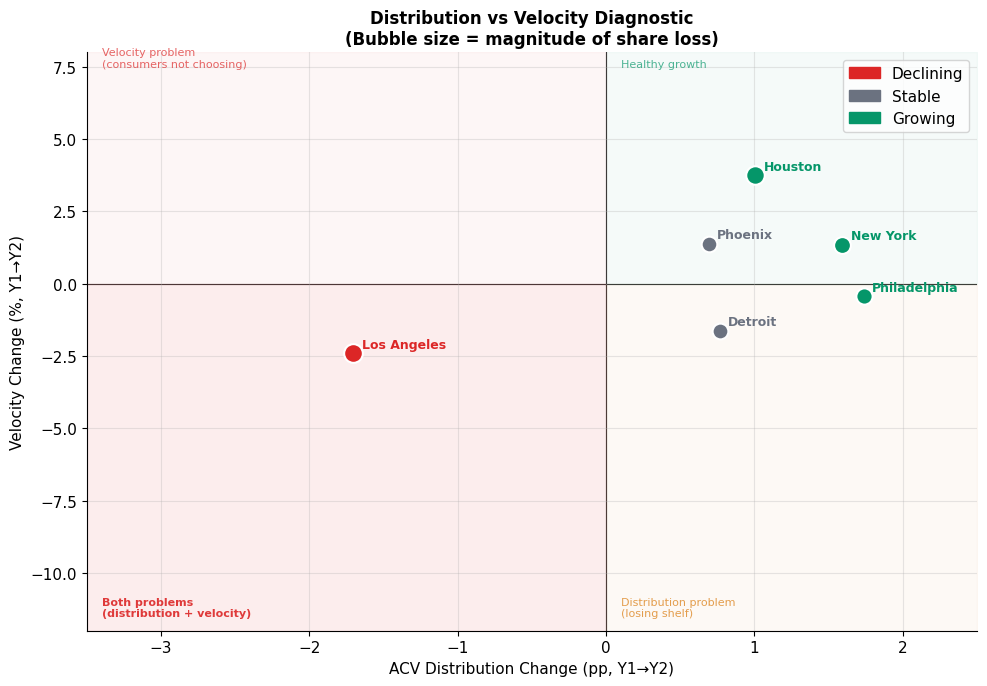

In [12]:
# 2×2 scatter: ACV change vs Velocity change
fig, ax = plt.subplots(figsize=(10, 7))

# Quadrant shading
ax.axvline(0, color='black', linewidth=0.8, zorder=1)
ax.axhline(0, color='black', linewidth=0.8, zorder=1)

xlim = (-3.5, 2.5)
ylim = (-12, 8)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Quadrant backgrounds
ax.fill_betweenx([0, ylim[1]], xlim[0], 0, alpha=0.04, color='#DC2626')  # top-left: vel loss
ax.fill_betweenx([ylim[0], 0], xlim[0], 0, alpha=0.08, color='#DC2626')  # bottom-left: both
ax.fill_betweenx([ylim[0], 0], 0, xlim[1], alpha=0.04, color='#D97706')  # bottom-right: acv loss rare
ax.fill_betweenx([0, ylim[1]], 0, xlim[1], alpha=0.04, color='#059669')  # top-right: healthy

# Quadrant labels
ax.text(xlim[0]+0.1, ylim[1]-0.5, 'Velocity problem\n(consumers not choosing)', fontsize=8, color='#DC2626', alpha=0.7)
ax.text(xlim[0]+0.1, ylim[0]+0.5, 'Both problems\n(distribution + velocity)', fontsize=8, color='#DC2626', alpha=0.9, fontweight='bold')
ax.text(0.1,         ylim[1]-0.5, 'Healthy growth', fontsize=8, color='#059669', alpha=0.7)
ax.text(0.1,         ylim[0]+0.5, 'Distribution problem\n(losing shelf)', fontsize=8, color='#D97706', alpha=0.7)

# Plot each market
for _, row in diagnostic.iterrows():
    color = MARKET_TYPE_COLORS[row['market_type']]
    size  = 120 + abs(row['change_pp']) * 60  # size = magnitude of share loss
    ax.scatter(row['acv_change_pp'], row['vel_change_pct'],
               color=color, s=size, zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(row['market'],
                xy=(row['acv_change_pp'], row['vel_change_pct']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)

patches = [mpatches.Patch(color=MARKET_TYPE_COLORS[t], label=t.capitalize())
           for t in ['declining', 'stable', 'growing']]
ax.legend(handles=patches, loc='upper right')
ax.set_xlabel('ACV Distribution Change (pp, Y1→Y2)', fontsize=11)
ax.set_ylabel('Velocity Change (%, Y1→Y2)', fontsize=11)
ax.set_title('Distribution vs Velocity Diagnostic\n(Bubble size = magnitude of share loss)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_diagnostic_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Luminos vs competitor ACV by channel (national avg)
channel_acv = (
    df.groupby(['brand', 'channel'])['acv_distribution']
    .mean()
    .reset_index()
    .rename(columns={'acv_distribution': 'avg_acv'})
)

pivot_channel = channel_acv.pivot(index='brand', columns='channel', values='avg_acv').round(3)
print('ACV Distribution by Brand × Channel (national avg):')
print(pivot_channel.to_string(float_format='{:.1%}'.format))

ACV Distribution by Brand × Channel (national avg):
channel        Drug  Food  Mass
brand                          
Dove          94.0% 94.0% 94.0%
Luminos       59.4% 71.4% 71.4%
Pantene       89.0% 89.0% 89.0%
Private Label 85.0% 85.0% 85.0%
Suave         91.0% 91.0% 91.0%


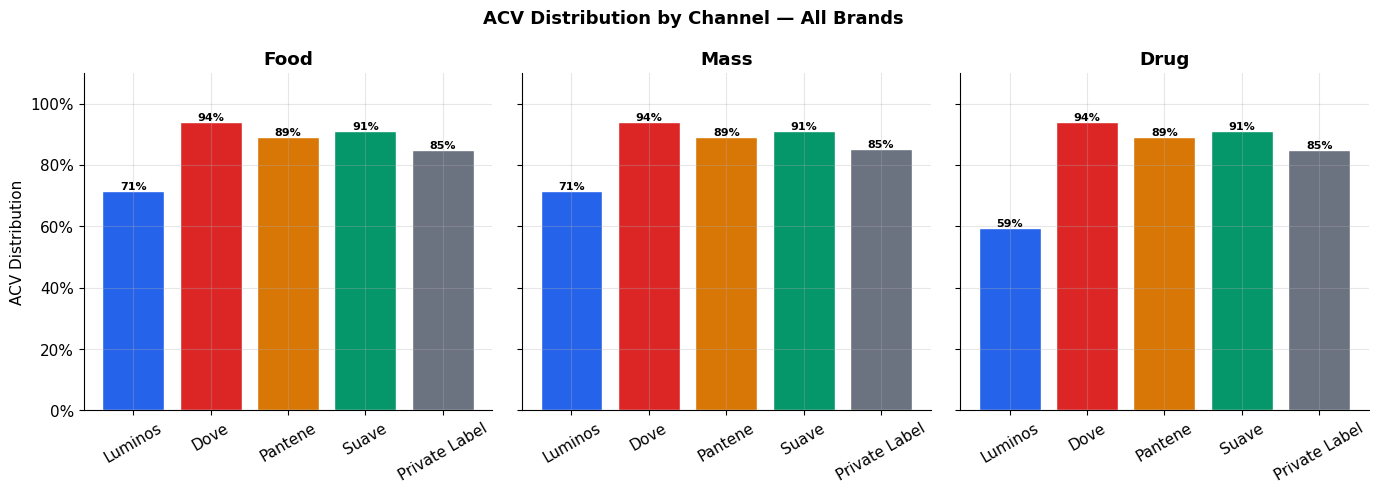

In [14]:
# Chart: ACV by brand and channel
channels = ['Food', 'Mass', 'Drug']
brands_ordered = ['Luminos', 'Dove', 'Pantene', 'Suave', 'Private Label']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle('ACV Distribution by Channel — All Brands', fontsize=13, fontweight='bold')

for ax, channel in zip(axes, channels):
    sub = channel_acv[channel_acv['channel'] == channel].set_index('brand')
    vals   = [sub.loc[b, 'avg_acv'] if b in sub.index else 0 for b in brands_ordered]
    colors = [BRAND_COLORS[b] for b in brands_ordered]
    bars   = ax.bar(brands_ordered, vals, color=colors, edgecolor='white')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.0%}', ha='center', fontsize=8, fontweight='bold')

    ax.set_title(channel, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('ACV Distribution' if channel == 'Food' else '')

plt.tight_layout()
plt.savefig('../outputs/02_acv_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Luminos ACV gap vs Dove (market leader) by channel in declining markets
declining_mkts = market_class[market_class['market_type'] == 'declining']['market'].tolist()

gap_data = (
    df[df['market'].isin(declining_mkts)]
    .groupby(['brand', 'channel'])['acv_distribution']
    .mean()
    .reset_index()
)

luminos_acv = gap_data[gap_data['brand'] == 'Luminos'].set_index('channel')['acv_distribution']
dove_acv    = gap_data[gap_data['brand'] == 'Dove'].set_index('channel')['acv_distribution']
gap_df = pd.DataFrame({
    'Luminos': luminos_acv,
    'Dove':    dove_acv,
    'Gap':     luminos_acv - dove_acv
}).reset_index()

print('Luminos vs Dove ACV Gap in DECLINING Markets (by channel):')
print(gap_df.to_string(index=False, float_format='{:.1%}'.format))

Luminos vs Dove ACV Gap in DECLINING Markets (by channel):
channel  Luminos  Dove    Gap
   Drug    56.3% 94.0% -37.7%
   Food    68.3% 94.0% -25.7%
   Mass    68.3% 94.1% -25.8%


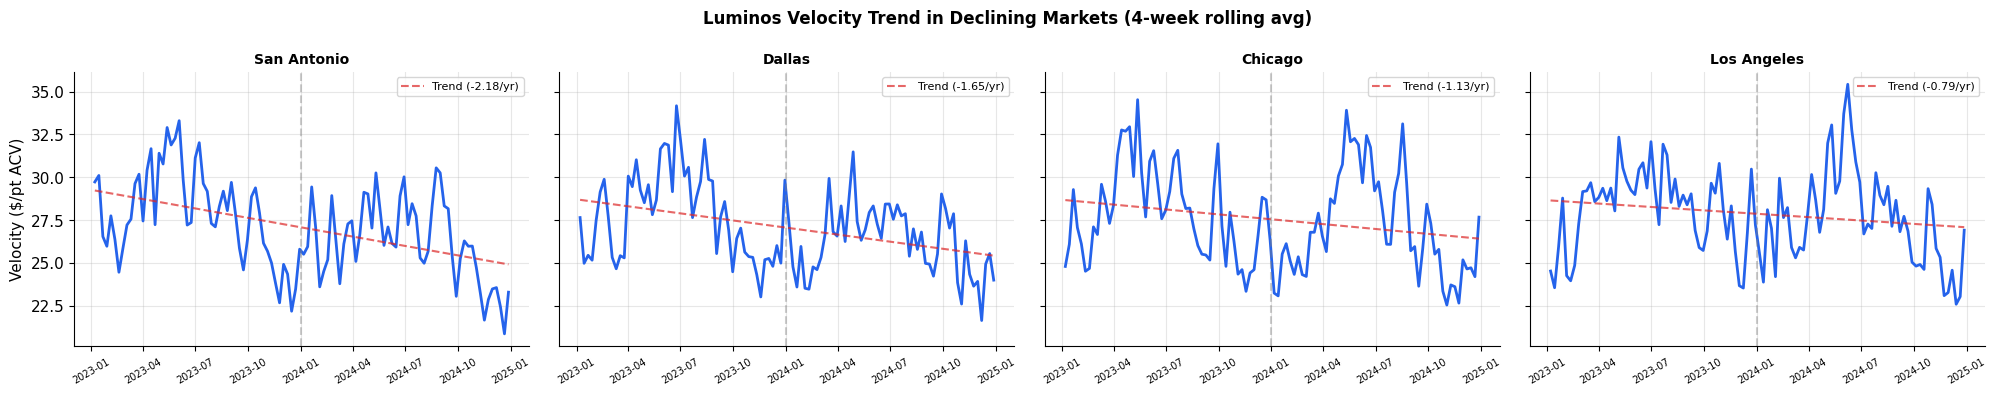

In [16]:
# Weekly velocity trend for Luminos in each declining market
luminos_dec = luminos_df[luminos_df['market'].isin(declining_mkts)].copy()
luminos_dec = luminos_dec.sort_values(['market', 'week_end_date'])
luminos_dec['vel_4w_ma'] = (
    luminos_dec.groupby('market')['velocity']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

fig, axes = plt.subplots(1, len(declining_mkts), figsize=(5 * len(declining_mkts), 4), sharey=True)
if len(declining_mkts) == 1:
    axes = [axes]
fig.suptitle('Luminos Velocity Trend in Declining Markets (4-week rolling avg)',
             fontsize=12, fontweight='bold')

for ax, market in zip(axes, declining_mkts):
    sub = luminos_dec[luminos_dec['market'] == market]
    # All channels aggregated already in luminos_df
    weekly_vel = sub.groupby('week_end_date')['vel_4w_ma'].mean()
    ax.plot(weekly_vel.index, weekly_vel.values, color='#2563EB', linewidth=2)
    ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle='--', alpha=0.4)

    # Trend line
    x_num = np.arange(len(weekly_vel))
    slope, intercept, *_ = stats.linregress(x_num, weekly_vel.values)
    ax.plot(weekly_vel.index, intercept + slope * x_num,
            color='#DC2626', linewidth=1.5, linestyle='--', alpha=0.7, label=f'Trend ({slope*52:.2f}/yr)')

    ax.set_title(market, fontsize=10, fontweight='bold')
    ax.set_ylabel('Velocity ($/pt ACV)' if market == declining_mkts[0] else '')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/02_velocity_declining_markets.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Auto-generate findings
luminos_nat_acv = national_acv[national_acv['brand'] == 'Luminos']['avg_acv'].values[0]
dove_nat_acv    = national_acv[national_acv['brand'] == 'Dove']['avg_acv'].values[0]
acv_gap         = (luminos_nat_acv - dove_nat_acv) * 100

luminos_nat_vel = national_velocity[national_velocity['brand'] == 'Luminos']['avg_velocity'].values[0]
dove_nat_vel    = national_velocity[national_velocity['brand'] == 'Dove']['avg_velocity'].values[0]

# Declining market diagnostics
dec_diag = diagnostic[diagnostic['market_type'] == 'declining']
velocity_led  = (dec_diag['driver'] == 'Velocity-led').sum()
both_led      = (dec_diag['driver'] == 'Both ACV & Velocity').sum()
dist_led      = (dec_diag['driver'] == 'Distribution-led').sum()

worst_vel_mkt  = vel_by_market.iloc[0]
worst_acv_mkt  = acv_by_market.iloc[0]

# Drug channel gap
drug_gap = gap_df[gap_df['channel'] == 'Drug']['Gap'].values[0] * 100

print('=' * 65)
print('  KEY FINDINGS — Distribution & Velocity Analysis')
print('=' * 65)
print(f"""
1. DISTRIBUTION GAP
   Luminos has {luminos_nat_acv:.0%} national ACV vs Dove at {dove_nat_acv:.0%} —
   a {abs(acv_gap):.1f} pp gap vs the category leader. Luminos is
   notably under-distributed in the Drug channel.

2. VELOCITY GAP
   Luminos velocity is ${luminos_nat_vel:.2f}/pt ACV vs Dove at
   ${dove_nat_vel:.2f}/pt ACV. Where Luminos has shelf presence,
   consumers are choosing it at a significantly lower rate.

3. PRIMARY DRIVER OF SHARE LOSS
   In declining markets: {velocity_led} velocity-led, {dist_led} distribution-led,
   {both_led} driven by both. The dominant problem is consumer
   pull (velocity), not shelf presence.

4. WORST VELOCITY MARKET
   {worst_vel_mkt['market']} shows the steepest velocity decline
   ({worst_vel_mkt['vel_change_pct']:+.1f}% Y1→Y2), indicating consumers
   are actively switching away from Luminos at shelf.

5. WORST ACV MARKET
   {worst_acv_mkt['market']} shows the largest ACV decline
   ({worst_acv_mkt['acv_change_pp']:+.2f} pp Y1→Y2), suggesting some
   retailer de-listing pressure as well.

6. CHANNEL FINDING
   Luminos's Drug channel ACV gap vs Dove in declining markets
   is {abs(drug_gap):.1f} pp — the largest channel gap observed.
   Drug is the most under-penetrated channel.

7. IMPLICATION
   Since velocity is the primary driver, the fix is NOT primarily
   about getting more shelf space. It is about why consumers
   prefer competitors AT shelf — pricing, promotion, and
   perceived value. → See Notebook 03: Price & Promo Analysis
""")
print('=' * 65)

  KEY FINDINGS — Distribution & Velocity Analysis

1. DISTRIBUTION GAP
   Luminos has 67% national ACV vs Dove at 94% —
   a 26.6 pp gap vs the category leader. Luminos is
   notably under-distributed in the Drug channel.

2. VELOCITY GAP
   Luminos velocity is $28.28/pt ACV vs Dove at
   $42.53/pt ACV. Where Luminos has shelf presence,
   consumers are choosing it at a significantly lower rate.

3. PRIMARY DRIVER OF SHARE LOSS
   In declining markets: 0 velocity-led, 0 distribution-led,
   4 driven by both. The dominant problem is consumer
   pull (velocity), not shelf presence.

4. WORST VELOCITY MARKET
   Dallas shows the steepest velocity decline
   (-5.9% Y1→Y2), indicating consumers
   are actively switching away from Luminos at shelf.

5. WORST ACV MARKET
   San Antonio shows the largest ACV decline
   (-4.93 pp Y1→Y2), suggesting some
   retailer de-listing pressure as well.

6. CHANNEL FINDING
   Luminos's Drug channel ACV gap vs Dove in declining markets
   is 37.7 pp — the l

In [18]:
# Save diagnostic table for use in Notebook 03
diagnostic.to_csv('../data/market_diagnostic.csv', index=False)
print('Saved: ../data/market_diagnostic.csv')
print('This feeds into Notebook 03: Price & Promo Analysis.')

Saved: ../data/market_diagnostic.csv
This feeds into Notebook 03: Price & Promo Analysis.
